# Flood Segmentation Showcase — where deep learning *does* win
**Dataset:** Sen1Floods11 hand-labeled (446 Sentinel-1 VV+VH chips + dense flood masks)

This is the deliberate counterpart to the V3 soil result. There, a per-pixel **GBM beat the
U-Net** because labels were 250 m SoilGrids (no real texture to learn) and the signal was
per-pixel (terrain-driven). Here the task has **dense pixel-level ground truth** and the target
(flood extent) has strong spatial structure — exactly the regime where a U-Net's spatial context
should help. We train both on identical chip splits and compare.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
P = Path("../data/processed_flood")
m = json.load(open(P/"flood_showcase_metrics.json"))
print(f"chips={m['n_chips']}  tile={m['size']}px")
print(f"{'model':24s} {'mIoU':>7s} {'F1(water)':>10s}")
print(f"{'GBM (per-pixel)':24s} {m['gbm']['miou']:7.3f} {m['gbm']['f1_water']:10.3f}")
print(f"{'U-Net (spatial)':24s} {m['unet']['miou']:7.3f} {m['unet']['f1_water']:10.3f}")
print(f"VERDICT: {m['verdict']}")

chips=446  tile=256px
model                       mIoU  F1(water)
GBM (per-pixel)            0.712      0.663
U-Net (spatial)            0.735      0.712
VERDICT: U-Net WINS (texture helps)


## Side-by-side predictions (test chips)
Columns: **Sentinel-1 VV** · **ground truth** · **GBM (per-pixel)** · **U-Net (spatial)**.
Water = bright. Note how the U-Net produces spatially coherent flood bodies, while the
per-pixel GBM is noisier along edges — the texture/context advantage.

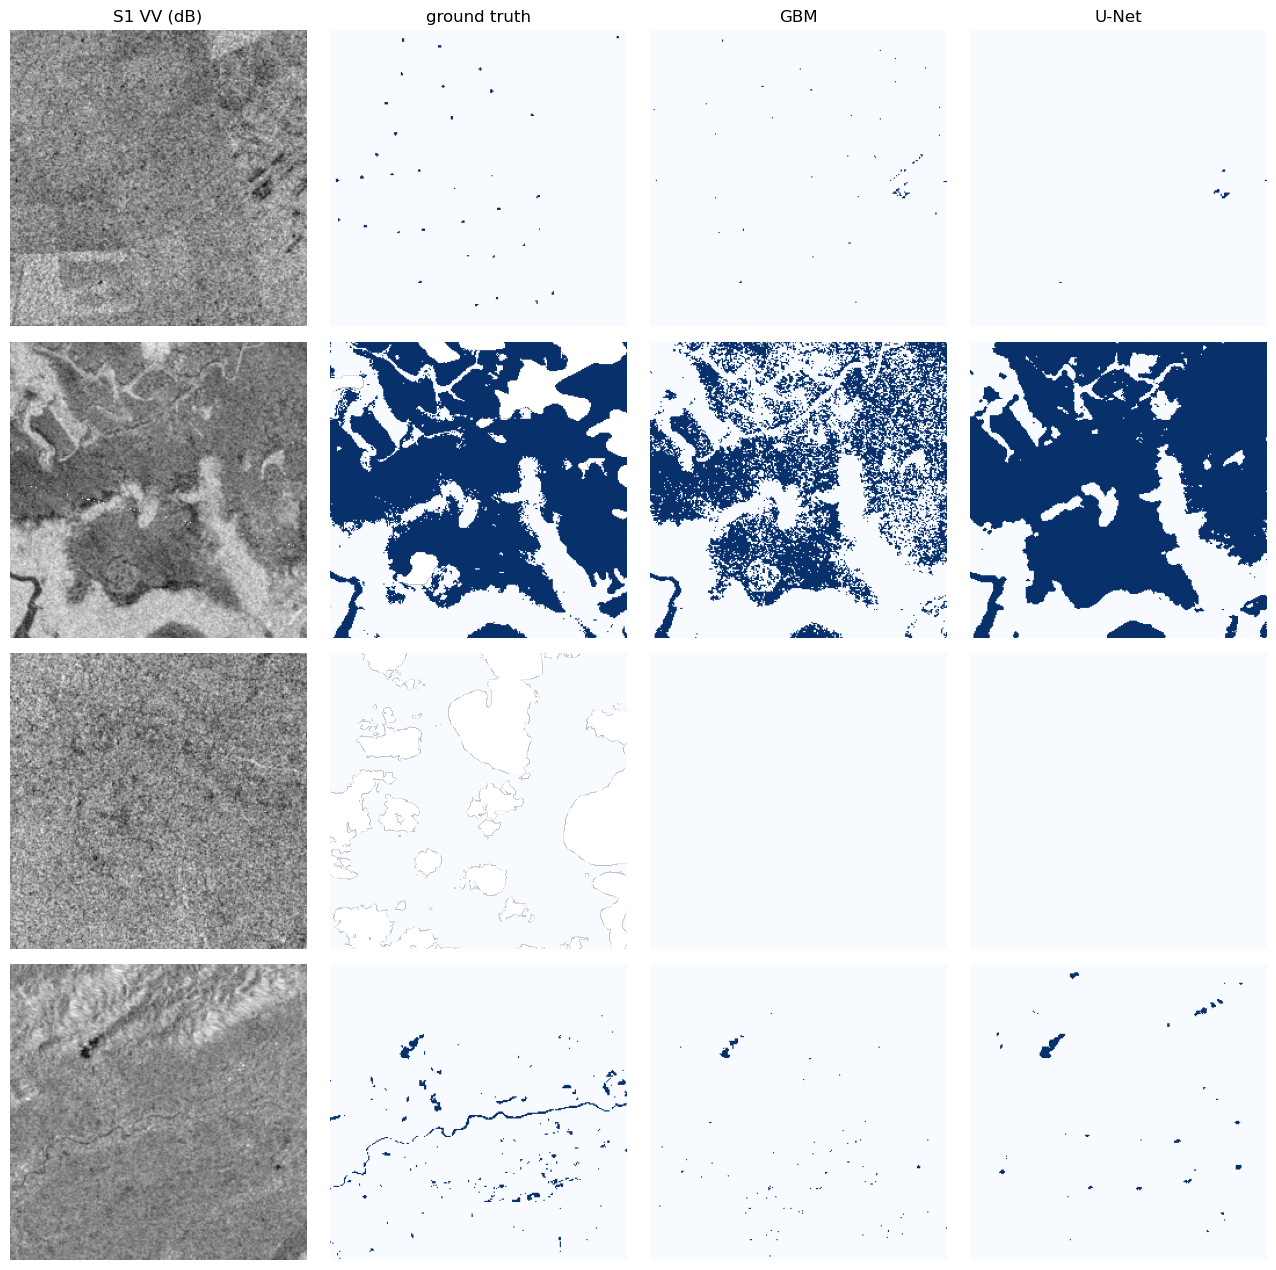

In [2]:
ex = np.load(P/"flood_examples.npz")
n = ex['vv'].shape[0]
fig, ax = plt.subplots(n, 4, figsize=(13, 3.2*n))
titles = ["S1 VV (dB)", "ground truth", "GBM", "U-Net"]
for r in range(n):
    vv, truth, gbm, unet = ex['vv'][r], ex['truth'][r], ex['gbm'][r], ex['unet'][r]
    truth = np.where(truth==255, np.nan, truth)
    ax[r,0].imshow(vv, cmap='gray')
    ax[r,1].imshow(truth, cmap='Blues', vmin=0, vmax=1)
    ax[r,2].imshow(gbm, cmap='Blues', vmin=0, vmax=1)
    ax[r,3].imshow(unet, cmap='Blues', vmin=0, vmax=1)
    for c in range(4):
        ax[r,c].axis('off')
        if r==0: ax[r,c].set_title(titles[c])
plt.tight_layout(); plt.show()

## The two results together — principled tool selection

| Task | Labels | Signal | Winner |
|---|---|---|---|
| **Soil** (V3) | 250 m SoilGrids (sparse, upsampled) | per-pixel (terrain) | **GBM** |
| **Flood** (this) | dense hand-drawn masks | spatial (extent/texture) | **U-Net** |

The same U-Net architecture, dataset, and training code (`soilgeo.models`) produced opposite
verdicts — and **both are correct**. Deep learning is not universally better; it wins when the
task has dense labels and genuine spatial structure to exploit. This is the honest, reusable
lesson: match the model to the label resolution and the nature of the signal, not to hype.